In [20]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt
from WBUtiles.WBClean import clean_wb_wide

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Description

Zambia Economic Performance dataset is collected from World Bank's World Development Indicators (WDI).

Copper Price dataset is collected from MacroTrends, https://www.macrotrends.net/1476/copper-prices-historical-chart-data

In [21]:
zambia_eco = pd.read_csv("../data/Zambia_EconomicPerformance/eco_perform.csv")
copper = pd.read_csv('../data/Other/macrotrend_copper_price.csv')
cpi = pd.read_csv("../data/Other/CPIAUCSL.csv")

In [22]:
base_year = 2015

copper["date"] = pd.to_datetime(copper["Date"])
copper["year"] = copper["date"].dt.year

annual_copper = (
    copper.groupby("year", as_index=False)
    .agg(
        nominal_copper_price=("Value", "mean"),
        observations=("Value", "count")
    )
)

cpi["DATE"] = pd.to_datetime(cpi["observation_date"])
cpi["year"] = cpi["DATE"].dt.year

annual_cpi = (
    cpi.groupby("year", as_index=False)
    .agg(cpi=("CPIAUCSL", "mean"))
)

df = annual_copper.merge(annual_cpi, on="year", how="left")
base_cpi = df.loc[df["year"] == base_year, "cpi"].iloc[0]

df["inflation_adjustment_factor"] = base_cpi / df["cpi"]
df["real_copper_price_2018_dollars"] = (
    df["nominal_copper_price"] * df["inflation_adjustment_factor"]
)

df["annual_inflation_rate"] = df["cpi"].pct_change()
df = df[
    [
        "year",
        "nominal_copper_price",
        "cpi",
        "annual_inflation_rate",
        "inflation_adjustment_factor",
        "real_copper_price_2018_dollars",
        "observations",
    ]
]

copper_real = df[["year", "real_copper_price_2018_dollars"]]
copper_real["growth_rate"] = (
    copper_real["real_copper_price_2018_dollars"].pct_change()* 100
)
print(copper_real.head())

   year  real_copper_price_2018_dollars  growth_rate
0  1959                        2.526440          NaN
1  1960                        2.389952    -5.402375
2  1961                        2.362844    -1.134273
3  1962                        2.291063    -3.037894
4  1963                        2.302576     0.502528


In [23]:
zambia_eco_clean, zambia_eco_lookup = clean_wb_wide(zambia_eco)
GDPPC_growth = zambia_eco_clean[['Year', 'NY.GDP.PCAP.KD.ZG']].dropna()
print(GDPPC_growth.head())

   Year  NY.GDP.PCAP.KD.ZG
1  1961          -1.764634
2  1962          -5.511066
3  1963           0.060076
4  1964           8.728433
5  1965          13.011976


Check correlationship between copper price and GDP per capita growth rate (NY.GDP.PCAP.KD.ZG) in Zambia.

In [24]:
# Align column names
gdp = GDPPC_growth.rename(columns={
    "Year": "year",
    "NY.GDP.PCAP.KD.ZG": "gdp_growth"
})

merged = copper_real.merge(gdp, on="year", how="inner")
merged = merged.dropna()

In [25]:
merged

,year,real_copper_price_2018_dollars,growth_rate,gdp_growth
0,1961,2.362844,-1.134273,-1.764634
1,1962,2.291063,-3.037894,-5.511066
2,1963,2.302576,0.502528,0.060076
3,1964,3.078994,33.719521,8.728433
4,1965,3.677751,19.446493,13.011976
...,...,...,...,...
59,2020,2.564786,1.644945,-5.567735
60,2021,3.712406,44.745245,3.285755
61,2022,3.227183,-13.070311,2.343365
62,2023,3.012503,-6.652252,2.464640


In [26]:
X = merged["growth_rate"]
y = merged["gdp_growth"]

X = sm.add_constant(X)  # adds intercept

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2.431
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.124
Time:                        20:25:49   Log-Likelihood:                -182.20
No. Observations:                  64   AIC:                             368.4
Df Residuals:                      62   BIC:                             372.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1895      0.533      0.356      

y = beta1 * x + beta0 + error, where y = Zambia_GDPPC_growth, x = copper_real_growth

- beta1 = 0.0396
- p-value = 0.124
- R2 = 0.038

Not statistically significant (p > 0.05): No meaningful same-year relationship between copper price growth and GDP per capita growth.



In [32]:
# time series lag
merged["copper_lag1"] = merged["growth_rate"].shift(1)

lagged = merged.dropna()

X = sm.add_constant(lagged["copper_lag1"])
y = lagged["gdp_growth"]

model_lag = sm.OLS(y, X).fit()
pearson_coef = lagged["copper_lag1"].corr(y)

print(model_lag.summary())
print(f"Pearson coefficient (copper_lag1 vs gdp_growth): {pearson_coef:.3f}")
print(f"OLS slope coefficient (copper_lag1): {model_lag.params['copper_lag1']:.4f}")

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     4.384
Date:                Sun, 03 May 2026   Prob (F-statistic):             0.0404
Time:                        20:36:44   Log-Likelihood:                -178.76
No. Observations:                  63   AIC:                             361.5
Df Residuals:                      61   BIC:                             365.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1939      0.532      0.364      

- beta1 = 0.0527
- Pearson coefficient = 0.259
- p-value = 0.040
- R2 = 0.067

Interpretation: Statistically significant at 5% with Positive relationship

A 1% increase in copper price growth last year is related with 0.053% increase in GDP per capita growth this year.

- Effect size is small
- R2 still very low: most variation unexplained

There is evidence that copper prices lead GDP, but weakly.

In [36]:
latex_table = model_lag.summary().as_latex()
print(latex_table)

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &   gdp\_growth    & \textbf{  R-squared:         } &     0.067   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.052   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     4.384   \\
\textbf{Date:}             & Sun, 03 May 2026 & \textbf{  Prob (F-statistic):} &   0.0404    \\
\textbf{Time:}             &     20:37:48     & \textbf{  Log-Likelihood:    } &   -178.76   \\
\textbf{No. Observations:} &          63      & \textbf{  AIC:               } &     361.5   \\
\textbf{Df Residuals:}     &          61      & \textbf{  BIC:               } &     365.8   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                      & \textbf{coef} &

In [28]:
# stationarity test
adfuller(merged["growth_rate"])
adfuller(merged["gdp_growth"])

(np.float64(-2.5524315889497484),
 np.float64(0.10323253324613613),
 3,
 60,
 {'1%': np.float64(-3.5443688564814813),
  '5%': np.float64(-2.9110731481481484),
  '10%': np.float64(-2.5931902777777776)},
 np.float64(279.447916904808))

- test stat = -2.55
- p-value = 0.103

Critical values: 5% = -2.91

Interpretation: fail to reject unit root, Series may be non-stationary
Non-stationary data means that regression can be misleading

But:
- These are growth rates, which are usually stationary
- not a huge red flag, but worth noting

In [29]:
# granger causality test
data = merged[["gdp_growth", "growth_rate"]].dropna()
grangercausalitytests(data, maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.2069  , p=0.0446  , df_denom=60, df_num=1
ssr based chi2 test:   chi2=4.4173  , p=0.0356  , df=1
likelihood ratio test: chi2=4.2693  , p=0.0388  , df=1
parameter F test:         F=4.2069  , p=0.0446  , df_denom=60, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0194  , p=0.1421  , df_denom=57, df_num=2
ssr based chi2 test:   chi2=4.3932  , p=0.1112  , df=2
likelihood ratio test: chi2=4.2445  , p=0.1198  , df=2
parameter F test:         F=2.0194  , p=0.1421  , df_denom=57, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.2414  , p=0.3038  , df_denom=54, df_num=3
ssr based chi2 test:   chi2=4.2070  , p=0.2400  , df=3
likelihood ratio test: chi2=4.0683  , p=0.2542  , df=3
parameter F test:         F=1.2414  , p=0.3038  , df_denom=54, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(4.206911653130039),
    np.float64(0.04463364682751396),
    np.float64(60.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(4.417257235786542),
    np.float64(0.03557717921888214),
    np.int64(1)),
   'lrtest': (np.float64(4.26927695213476),
    np.float64(0.03880744026827765),
    np.int64(1)),
   'params_ftest': (np.float64(4.206911653130023),
    np.float64(0.04463364682751442),
    np.float64(60.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.019443592540025),
    np.float64(0.14211668836467578),
    np.float64(57.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(4.393175534648476),
    np.float64(0.1111818903131694),
    np.int64(2)),
   'lrtest': (np.float64(4.244513059882593),
    np.float64(0.11976107891425299),
    np.int64(2)),
   'params_ftest': (np.float64(2.019443592540023),
    np.float64(0.14211668836467595),
    np.float64(57.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0

Lag = 1: p = 0.04
Lag = 2, 3: Not significant

Interpretation: Copper growth Granger-causes GDP growth at 1-year lag only

Meaning: Past copper price changes contain predictive information about GDP growth

- Only short-term (1 year)
- Effect disappears with longer lags

# Plot

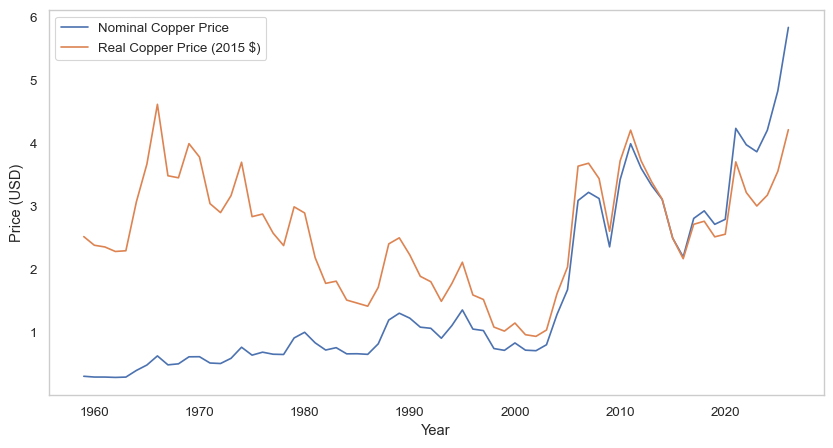

In [37]:
# plot copper price (df["nominal_copper_price"])
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["nominal_copper_price"], label="Nominal Copper Price")
ax.plot(df["year"], df["real_copper_price_2018_dollars"], label="Real Copper Price (2015 $)")
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD)")
# ax.set_title("Copper Price Over Time")
ax.legend()
ax.grid(False)

plt.savefig("../figures/copper_price_trends.pdf", format="pdf", bbox_inches="tight")